Referemce:

https://sites.google.com/view/automatic-prompt-engineer

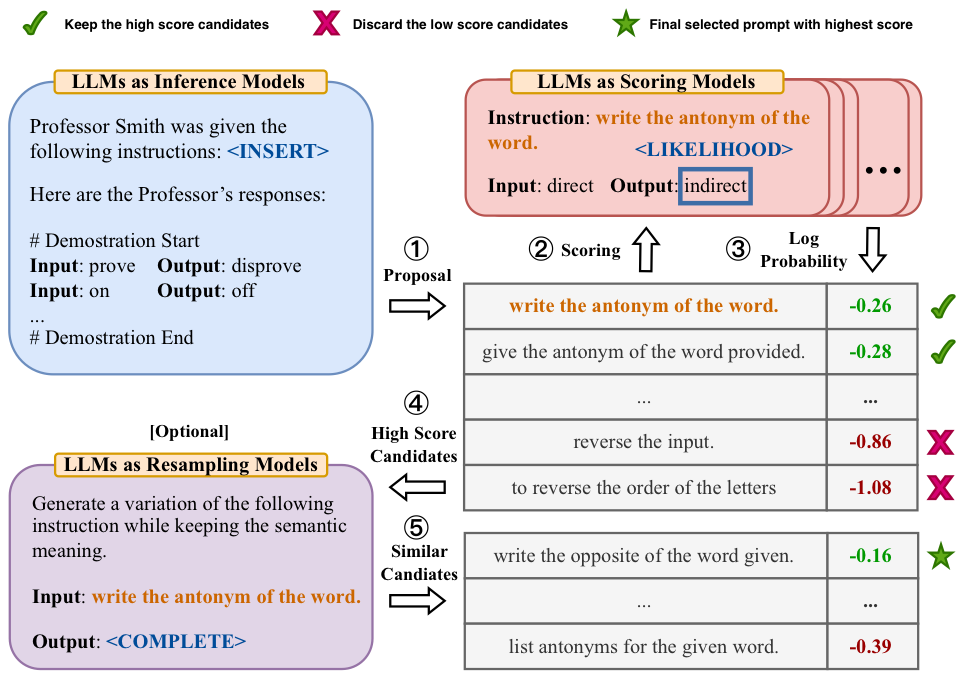

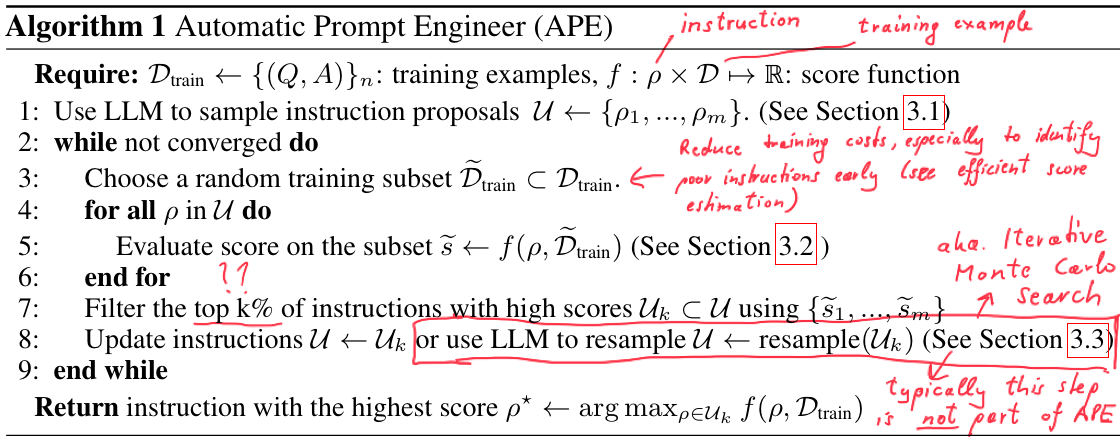

**Optimizing Prompts with Automatic Prompt Engineer (APE)**

This notebook demonstrates how to use Automatic Prompt Engineer (APE) (arxiv link) to optimize prompts for text generation. In its simplest form, APE takes as input a dataset (a list of inputs and a list of outputs), a prompt template, and optimizes this prompt template so that it generates the outputs given the inputs.

APE accomplishes this in two steps. First, it uses a language model to generate a set of candidate prompts. Then, it uses a prompt evaluation function to evaluate the quality of each candidate prompt. Finally, it returns the prompt with the highest evaluation score.

In [5]:
import random
import time
import os
from tqdm import tqdm
from abc import ABC, abstractmethod
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv(os.path.join("..", ".env"), override=True)

client = OpenAI()

In [6]:
# Handles the formatting of prompts for generation and evaluation.

class GenerationTemplate:
    def __init__(self, template):
        self.template = template
        assert self.template.count('[APE]') == 1

    def fill(self, full_demo='', input='', output=''):
        return self.template.replace('[full_DEMO]', full_demo).replace(
            '[INPUT]', input).replace('[OUTPUT]', output)

class EvalTemplate:
    def __init__(self, template):
        self.template = template

    def fill(self, prompt='', full_demo='', input='', output=''):
        return self.template.replace('[PROMPT]', prompt).replace(
            '[full_DEMO]', full_demo).replace('[INPUT]', input).replace('[OUTPUT]', output)

    def convert_to_generation_template(self):
        return GenerationTemplate(self.template.replace('[PROMPT]', '[APE]'))

class DemosTemplate:
    def __init__(self, template, delimiter='\n\n'):
        self.template = template
        self.delimiter = delimiter

    def fill(self, data):
        demos = ''
        for i, (input_, output_) in enumerate(zip(*data)):
            demos += self.template.replace('[INPUT]', input_).replace('[OUTPUT]', output_)
            if i != len(data[0]) - 1:
                demos += self.delimiter
        return demos

In [7]:
# Data & Mocked Configs (from data.py & config.py)
# Replaces external YAML configs with hardcoded python dictionaries.

def subsample_data(data, subsample_size):
    inputs, outputs = data
    assert len(inputs) == len(outputs)
    indices = random.sample(range(len(inputs)), subsample_size)
    inputs = [inputs[i] for i in indices]
    outputs = [outputs[i] for i in indices]
    return inputs, outputs

def simple_config(eval_model, prompt_gen_model, num_prompts, eval_rounds):
    """
    Simulates the merging of configs/default.yaml and configs/bandits.yaml
    REEMPLAZAR: Si tienes los verdaderos archivos YAML en el futuro, 
    puedes reemplazar este diccionario por la carga real usando yaml.safe_load().
    """
    conf = {
        'generation': {
            'model_name': prompt_gen_model,
            'num_subsamples': max(1, num_prompts // 10),
            'num_prompts_per_subsample': 10,
            'num_demos': 5
        },
        'evaluation': {
            'model_name': eval_model,
            'num_prompts_per_round': 0.334,
            'rounds': eval_rounds,
            'num_samples': 5 # Fixed low for quick demo
        },
        'demo': {
            'model_name': eval_model
        }
    }
    return conf

In [8]:
# Migrated from legacy Completion API to Chat Completions with gpt-4o-mini

def generate_text_chat(prompt, model_name, n=1):
    """
    Generates text using the modern OpenAI Chat API.
    """
    # Clean the [APE] token if present as generation shouldn't output it
    if isinstance(prompt, str):
        prompt = prompt.replace('[APE]', '').strip()
        
    response = None
    while response is None:
        try:
            response = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": prompt}],
                n=n,
                max_tokens=100, # Keeping output short
                temperature=0.7
            )
        except Exception as e:
            print(f"API Error: {e}. Retrying in 5s...")
            time.sleep(5)
            
    return [choice.message.content.strip() for choice in response.choices]

In [9]:
# Generate & Evaluate (from generate.py & evaluate.py)
# Evaluation uses a custom exact-match strategy since bandits.py wasn't provided.

def generate_prompts(prompt_gen_template, demos_template, prompt_gen_data, config):
    queries = []
    for _ in range(config['num_subsamples']):
        subsampled_data = subsample_data(prompt_gen_data, config['num_demos'])
        demos = demos_template.fill(subsampled_data)
        query = prompt_gen_template.fill(
            input=subsampled_data[0][0], 
            output=subsampled_data[1][0], 
            full_demo=demos
        )
        queries.append(query)

    print('Sending queries to LLM to generate prompts...')
    prompts = []
    for query in tqdm(queries):
        generated = generate_text_chat(query, config['model_name'], n=config['num_prompts_per_subsample'])
        prompts.extend(generated)
    return prompts

class EvaluationResult:
    def __init__(self, scores):
        self.scores = scores
    
    def sorted(self):
        return sorted(self.scores.items(), key=lambda x: x[1], reverse=True)

def evaluate_prompts_custom(prompts, eval_template, eval_data, config):
    """
    Custom exact-match evaluator to replace the missing 'bandits/likelihood' modules.
    It passes the prompt and the input to the LLM, and checks if the output matches.
    """
    scores = {p: 0 for p in prompts}
    inputs, outputs = eval_data
    num_samples = min(config['num_samples'], len(inputs))
    
    # Subsample test set for faster eval
    eval_indices = random.sample(range(len(inputs)), num_samples)
    
    print('Evaluating prompts with LLM...')
    for prompt in tqdm(prompts):
        correct = 0
        for idx in eval_indices:
            # We omit [OUTPUT] so the model has to guess it
            query = eval_template.fill(prompt=prompt, input=inputs[idx], output="").strip()
            
            prediction = generate_text_chat(query, config['model_name'], n=1)[0]
            
            # Simple Exact Match logic
            if outputs[idx].lower() in prediction.lower():
                correct += 1
                
        scores[prompt] = correct / num_samples
        
    return EvaluationResult(scores)

def demo_function(eval_template, model_name):
    """Returns a function to manually test the best prompt."""
    def fn(prompt, inputs):
        if not isinstance(inputs, list):
            inputs = [inputs]
        results = []
        for input_ in inputs:
            query = eval_template.fill(prompt=prompt, input=input_, output="").strip()
            pred = generate_text_chat(query, model_name, n=1)[0]
            results.append(pred)
        return results
    return fn

In [12]:
# APE Core functions (from ape.py)
# Glues generation and evaluation together into the simple_ape interface.

def get_simple_prompt_gen_template(prompt_gen_template):
    if prompt_gen_template is None:
        # Default zero-shot generation prompt used by APE
        prompt_gen_template = "I gave a friend an instruction. Based on the instruction they produced the following input-output pairs:\n\n[full_DEMO]\n\nThe instruction was to [APE]"
    return prompt_gen_template

def find_prompts(eval_template_str, demos_template_str, dataset, conf, prompt_gen_template_str=None):
    eval_template = EvalTemplate(eval_template_str)
    demos_template = DemosTemplate(demos_template_str)
    
    if prompt_gen_template_str is None:
        prompt_gen_template = eval_template.convert_to_generation_template()
    else:
        prompt_gen_template = GenerationTemplate(prompt_gen_template_str)

    print('Generating prompts...')
    prompts = generate_prompts(prompt_gen_template, demos_template, dataset, conf['generation'])

    prompts = list(set(prompts)) # Deduplicate
    print(f'Deduplicated to {len(prompts)} prompts.')

    res = evaluate_prompts_custom(prompts, eval_template, dataset, conf['evaluation'])
    print('Finished evaluating.')

    demo_fn = demo_function(eval_template, conf['demo']['model_name'])
    return res, demo_fn

def simple_ape(dataset,
               eval_template='Instruction: [PROMPT]\nInput: [INPUT]\nOutput: [OUTPUT]',
               prompt_gen_template=None,
               demos_template='Input: [INPUT]\nOutput: [OUTPUT]',
               eval_model='gpt-4o-mini',
               prompt_gen_model='gpt-4o-mini',
               num_prompts=10, # Reduced default for cheaper execution
               eval_rounds=1):
               
    prompt_gen_template_str = get_simple_prompt_gen_template(prompt_gen_template)
    
    conf = simple_config(eval_model, prompt_gen_model, num_prompts, eval_rounds)
    
    # CORRECCIÓN AQUÍ: Cambiamos prompt_gen_template= a prompt_gen_template_str=
    return find_prompts(eval_template, demos_template, dataset, conf, prompt_gen_template_str=prompt_gen_template_str)

In [13]:
# Run the Experiment!

words = ["sane", "direct", "informally", "unpopular", "subtractive", "nonresidential",
         "inexact", "uptown", "incomparable", "powerful", "gaseous", "evenly", "formality",
         "deliberately", "off"]
antonyms = ["insane", "indirect", "formally", "popular", "additive", "residential",
            "exact", "downtown", "comparable", "powerless", "solid", "unevenly", "informality",
            "accidentally", "on"]
            
eval_template = """Instruction: [PROMPT]
Input: [INPUT]
Output: [OUTPUT]"""

# Corremos la optimización de APE
result, demo_fn = simple_ape(
    dataset=(words, antonyms),
    eval_template=eval_template,
)

# Imprimimos los resultados
print("\n--- Top Prompts Evaluados ---")
sorted_results = result.sorted()
for prompt, score in sorted_results[:5]:
    print(f"Score: {score:.2f} | Prompt: {prompt}")

# Usamos la función de prueba (demo_fn) con el mejor prompt
best_prompt = sorted_results[0][0]
test_words = ["happy", "fast", "inside"]
predictions = demo_fn(best_prompt, test_words)

print("\n--- Prueba del mejor prompt ---")
for w, p in zip(test_words, predictions):
    print(f"Input: {w} -> Model Prediction: {p}")

Generating prompts...
Sending queries to LLM to generate prompts...


100%|██████████| 1/1 [00:03<00:00,  3.37s/it]


Deduplicated to 9 prompts.
Evaluating prompts with LLM...


100%|██████████| 9/9 [00:32<00:00,  3.58s/it]


Finished evaluating.

--- Top Prompts Evaluados ---
Score: 1.00 | Prompt: The instruction was to provide antonyms for the given words. Each output represents a word that has the opposite meaning of the corresponding input word.
Score: 1.00 | Prompt: The instruction was likely to produce antonyms or opposites for the given words. Each input word is paired with a word that has an opposing meaning.
Score: 1.00 | Prompt: The instruction was likely to produce antonyms for the given words. Each input word is paired with its opposite meaning in the output.
Score: 1.00 | Prompt: The instruction was to provide antonyms for the given words. Each output is a word that has the opposite meaning of the corresponding input word.
Score: 1.00 | Prompt: The instruction was to provide antonyms for the given words. Each output is the opposite or a contrasting term to the input word.

--- Prueba del mejor prompt ---
Input: happy -> Model Prediction: sad
Input: fast -> Model Prediction: slow
Input: inside -